# XGBoost Regression - Network Throughput Prediction

Target: `Data Throughput (Mbps)`

Features: `Locality`, `Latitude`, `Longitude`, `Signal Strength (dBm)`, `Latency (ms)`, `Network Type`

## 1. Clone repo (Colab only)


In [1]:
!git clone https://github.com/MohamedAAbdullah1/NTI-Final-Project.git
%cd NTI-Final-Project

Cloning into 'NTI-Final-Project'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 71 (delta 23), reused 38 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 3.11 MiB | 6.50 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/NTI-Final-Project


## Environment Setup and Imports

The required libraries are imported to support data preprocessing, XGBoost Regression, model evaluation, and model persistence.

In [13]:
import os
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV

## Load Training and Testing Data

The prepared training and testing datasets are loaded from the processed data directory.

The predefined train-test split is reused to ensure consistency and fairness when comparing XGBoost with the other regression models.

In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

print("\nTraining features:")
print(X_train.head())

X_train: (13463, 6) | y_train: (13463,)
X_test : (3366, 6) | y_test : (3366,)

Training features:
          Locality   Latitude  Longitude  Signal Strength (dBm)  Latency (ms)  \
0      Pataliputra  25.605539  85.285651             -87.611830    164.101054   
1       Kidwaipuri  25.491973  85.086669             -90.089704     22.851745   
2          Danapur  25.684972  84.989785             -90.175391    139.812003   
3       Kankarbagh  25.569868  85.138714             -93.384826    113.904981   
4  Phulwari Sharif  25.626811  85.136823             -95.888704     71.291449   

  Network Type  
0           4G  
1           5G  
2           4G  
3           4G  
4           4G  


## Define Numerical and Categorical Features

The input features are divided into numerical and categorical groups to apply the appropriate preprocessing strategy before training the XGBoost model.

In [4]:
numerical_features = [
    "Latitude",
    "Longitude",
    "Signal Strength (dBm)",
    "Latency (ms)"
]

categorical_features = [
    "Locality",
    "Network Type"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Latitude', 'Longitude', 'Signal Strength (dBm)', 'Latency (ms)']

Categorical features:
['Locality', 'Network Type']


## Configure Feature Preprocessing

Numerical features are passed through without scaling because XGBoost is a tree-based model and does not require feature standardization.

Categorical features are transformed using OneHotEncoder to convert categorical values into a numerical representation suitable for XGBoost.

In [6]:
xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("XGBoost preprocessing pipeline configured successfully.")

XGBoost preprocessing pipeline configured successfully.


## Construct the XGBoost Regression Pipeline

A unified machine learning pipeline is created by combining feature preprocessing with the XGBoost regression model.

The initial XGBoost configuration uses a relatively small learning rate and shallow trees to provide a controlled baseline before any further hyperparameter optimization.

In [8]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            xgb_preprocessor
        ),
        (
            "model",
            xgb.XGBRegressor(
                n_estimators=200,
                max_depth=3,
                learning_rate=0.03,
                subsample=1.0,
                colsample_bytree=0.9,
                min_child_weight=7,
                gamma=0.3,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


## Train the XGBoost Regression Model

The XGBoost pipeline is trained using the prepared training dataset.

The preprocessing stage is fitted on the training data before the transformed features are passed to the XGBoost regression model.

In [9]:
xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## Generate Training and Testing Predictions

The trained XGBoost pipeline is used to generate throughput predictions for both the training and testing datasets.

The predictions will be used to evaluate model performance and assess its generalization to unseen data.

In [10]:
y_pred_train = xgb_pipeline.predict(X_train)
y_pred_test = xgb_pipeline.predict(X_test)

print("Training predictions generated:", y_pred_train.shape)
print("Testing predictions generated :", y_pred_test.shape)

Training predictions generated: (13463,)
Testing predictions generated : (3366,)


## Evaluate XGBoost Regression Performance

The XGBoost model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

Both training and testing performance are reported to assess prediction accuracy and generalization to unseen data.

In [11]:
train_mae = mean_absolute_error(y_train, y_pred_train)
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_pred_train)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

print("Training Performance")
print(f"MAE  : {train_mae:.4f}")
print(f"MSE  : {train_mse:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

print("\nTest Performance")
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

Training Performance
MAE  : 6.1720
MSE  : 162.8574
RMSE : 12.7616
R²   : 0.7523

Test Performance
MAE  : 6.4581
MSE  : 177.6823
RMSE : 13.3298
R²   : 0.7359


## Visualize Actual vs Predicted Throughput

The actual and predicted throughput values are visualized to assess how closely the XGBoost predictions follow the observed target values.

The reference line represents ideal predictions, where the predicted throughput is equal to the actual throughput.

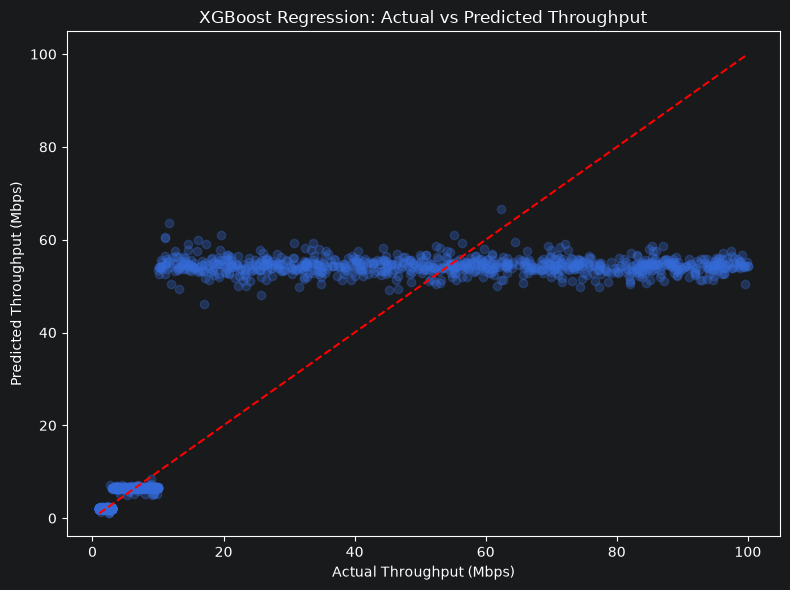

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Throughput (Mbps)")
plt.ylabel("Predicted Throughput (Mbps)")
plt.title("XGBoost Regression: Actual vs Predicted Throughput")

plt.tight_layout()
plt.show()

## Define XGBoost Hyperparameter Search Space

A focused hyperparameter search space is defined to explore different XGBoost configurations.

The search focuses on parameters that control model complexity, learning rate, tree structure, and feature and sample subsampling.

In [16]:
param_distributions = {
    "model__n_estimators": [100, 150, 200, 250],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.02, 0.03, 0.05, 0.07],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.3, 0.5],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

print("Hyperparameter search space configured successfully.")

Hyperparameter search space configured successfully.


## Optimize XGBoost Using Cross-Validation

Randomized cross-validation is used to evaluate a limited number of XGBoost configurations from the defined search space.

Mean Absolute Error is used as the optimization metric because it provides a direct and interpretable measure of the average prediction error in Mbps.

In [17]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(
    X_train,
    y_train
)

print("XGBoost hyperparameter search completed successfully.")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
XGBoost hyperparameter search completed successfully.


## Identify the Optimal XGBoost Configuration

The best XGBoost configuration identified by cross-validation is retrieved and compared using the Mean Absolute Error score.

The negative cross-validation score is converted to a positive MAE value for easier interpretation.

In [18]:
best_xgb_pipeline = xgb_search.best_estimator_

best_cv_mae = -xgb_search.best_score_

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print(f"\nBest Cross-Validation MAE: {best_cv_mae:.4f}")

Best XGBoost Parameters:
{'model__subsample': 0.9, 'model__n_estimators': 250, 'model__min_child_weight': 1, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__gamma': 0.5, 'model__colsample_bytree': 0.9}

Best Cross-Validation MAE: 6.3152


## Evaluate the Optimized XGBoost Model

The optimized XGBoost pipeline is evaluated on both the training and testing datasets.

The test performance is compared with the baseline model to determine whether hyperparameter optimization improved the model's ability to generalize to unseen data.

In [19]:
optimized_pred_train = best_xgb_pipeline.predict(X_train)
optimized_pred_test = best_xgb_pipeline.predict(X_test)

optimized_train_mae = mean_absolute_error(
    y_train,
    optimized_pred_train
)

optimized_train_mse = mean_squared_error(
    y_train,
    optimized_pred_train
)

optimized_train_rmse = np.sqrt(
    optimized_train_mse
)

optimized_train_r2 = r2_score(
    y_train,
    optimized_pred_train
)

optimized_test_mae = mean_absolute_error(
    y_test,
    optimized_pred_test
)

optimized_test_mse = mean_squared_error(
    y_test,
    optimized_pred_test
)

optimized_test_rmse = np.sqrt(
    optimized_test_mse
)

optimized_test_r2 = r2_score(
    y_test,
    optimized_pred_test
)

print("Optimized XGBoost - Training Performance")
print(f"MAE  : {optimized_train_mae:.4f}")
print(f"MSE  : {optimized_train_mse:.4f}")
print(f"RMSE : {optimized_train_rmse:.4f}")
print(f"R²   : {optimized_train_r2:.4f}")

print("\nOptimized XGBoost - Test Performance")
print(f"MAE  : {optimized_test_mae:.4f}")
print(f"MSE  : {optimized_test_mse:.4f}")
print(f"RMSE : {optimized_test_rmse:.4f}")
print(f"R²   : {optimized_test_r2:.4f}")

print("\nBaseline vs Optimized Test MAE")
print(f"Baseline : {test_mae:.4f}")
print(f"Optimized: {optimized_test_mae:.4f}")

Optimized XGBoost - Training Performance
MAE  : 6.2215
MSE  : 165.5219
RMSE : 12.8655
R²   : 0.7483

Optimized XGBoost - Test Performance
MAE  : 6.4661
MSE  : 177.2578
RMSE : 13.3138
R²   : 0.7365

Baseline vs Optimized Test MAE
Baseline : 6.4581
Optimized: 6.4661


## Select the Final XGBoost Model

The baseline XGBoost pipeline is selected as the final model because it achieved a lower test MAE than the optimized configuration.

Although the optimized configuration slightly improved RMSE and R², the increase in MAE does not justify replacing the baseline model.

In [20]:
final_xgb_pipeline = xgb_pipeline

print("Final XGBoost model selected: Baseline configuration.")

print("\nFinal Test Performance")
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

Final XGBoost model selected: Baseline configuration.

Final Test Performance
MAE  : 6.4581
MSE  : 177.6823
RMSE : 13.3298
R²   : 0.7359


## Visualize Final XGBoost Predictions

The final XGBoost model predictions are visualized against the actual throughput values from the testing dataset.

The reference line represents ideal predictions, where predicted values exactly match the observed throughput.

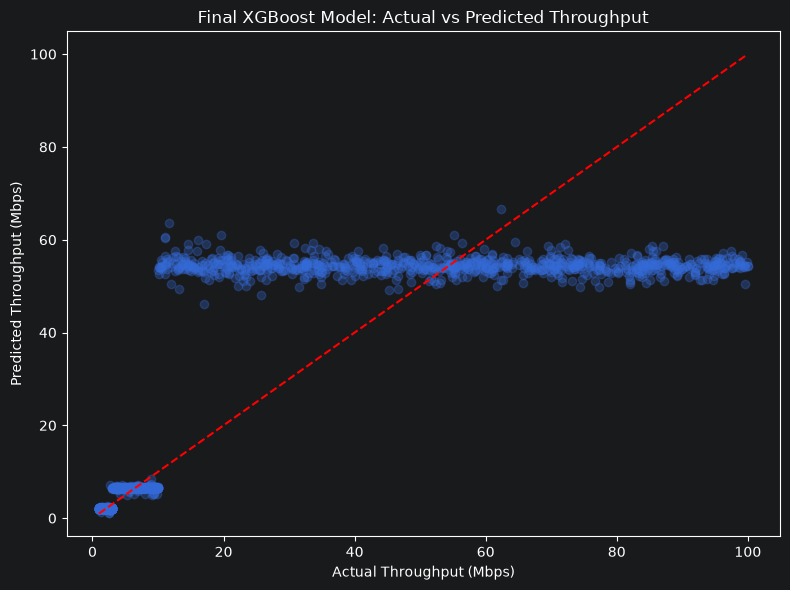

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Throughput (Mbps)")
plt.ylabel("Predicted Throughput (Mbps)")
plt.title("Final XGBoost Model: Actual vs Predicted Throughput")

plt.tight_layout()
plt.show()

## Save the Final XGBoost Pipeline

The final XGBoost pipeline is saved as a Joblib file for later deployment.

Saving the complete pipeline preserves both the preprocessing steps and the trained model, allowing the same transformations to be applied automatically when new data is provided to the deployed application.

In [22]:
model_path = "../models/xgboost.joblib"

joblib.dump(
    final_xgb_pipeline,
    model_path
)

print(f"Final XGBoost pipeline saved successfully to: {model_path}")

Final XGBoost pipeline saved successfully to: ../models/xgboost.joblib
